# Flow Matching Variants and Modern Practice

The base rectified-flow model already gives a complete image generator. The variants below examine the practical choices that determine generation quality: solver accuracy, path design, conditioning, and distribution-level evaluation.

The practical discussion focuses on solver accuracy, path design, conditioning, and repeated evaluation. These choices determine how the same base flow-matching objective behaves in practice.

```{important}
The main **engineering degrees of freedom** in flow matching are solver choice, path design, conditioning, and evaluation. These choices often matter as much as the base loss itself.
```

## Shared Setup and Solver Choices

The variants use the same FashionMNIST preprocessing and compact U-Net backbone as the base image model. Keeping this setup fixed makes comparisons about **solver choice**, **path design**, and **conditioning** easier to interpret.

In [15]:
import copy
import math
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
from torchvision import datasets, transforms, utils
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(7)
if device.type == "cuda":
    torch.cuda.manual_seed_all(7)

num_workers = 0
project_root = Path.cwd() if (Path.cwd() / "_config.yml").exists() else Path.cwd().parent
DATA_ROOT = project_root / "data"
CHECKPOINT_DIR = project_root / "artifacts" / "checkpoints"
RECTIFIED_FLOW_CHECKPOINT = CHECKPOINT_DIR / "fashionmnist_rectified_flow.pt"

image_batch_size = 128
image_size = 28
image_channels = 1
image_base_channels = 64
image_time_dim = 128
image_epochs = 35
image_lr = 2e-4
image_ode_steps = 100

image_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 2.0 * x - 1.0),
])

fashion_train = datasets.FashionMNIST(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=image_transform,
)

fashion_loader = DataLoader(
    fashion_train,
    batch_size=image_batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda"),
)


In [16]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        factor = math.log(10000.0) / max(half_dim - 1, 1)
        frequencies = torch.exp(torch.arange(half_dim, device=t.device) * -factor)
        angles = t * frequencies.unsqueeze(0)
        emb = torch.cat([angles.sin(), angles.cos()], dim=1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb


class ImageResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.time_mlp = nn.Linear(time_dim, out_channels)
        self.norm1 = nn.GroupNorm(8, out_channels)
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.activation = nn.SiLU()
        self.residual = (
            nn.Conv2d(in_channels, out_channels, kernel_size=1)
            if in_channels != out_channels else nn.Identity()
        )

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = self.activation(h)
        h = h + self.time_mlp(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = self.conv2(h)
        h = self.norm2(h)
        h = self.activation(h)
        return h + self.residual(x)


class ImageVelocityUNet(nn.Module):
    def __init__(self, in_channels=1, base_channels=64, time_dim=128):
        super().__init__()
        self.time_embedding = nn.Sequential(
            TimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )
        self.input_conv = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)
        self.down1 = ImageResidualBlock(base_channels, base_channels, time_dim)
        self.downsample1 = nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1)
        self.down2 = ImageResidualBlock(base_channels * 2, base_channels * 2, time_dim)
        self.downsample2 = nn.Conv2d(base_channels * 2, base_channels * 4, kernel_size=4, stride=2, padding=1)
        self.down3 = ImageResidualBlock(base_channels * 4, base_channels * 4, time_dim)
        self.mid = ImageResidualBlock(base_channels * 4, base_channels * 4, time_dim)
        self.upsample2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=4, stride=2, padding=1)
        self.up2 = ImageResidualBlock(base_channels * 4, base_channels * 2, time_dim)
        self.upsample1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=4, stride=2, padding=1)
        self.up1 = ImageResidualBlock(base_channels * 2, base_channels, time_dim)
        self.output_conv = nn.Conv2d(base_channels, in_channels, kernel_size=1)

    def forward(self, x, t):
        t_emb = self.time_embedding(t)
        x0 = self.input_conv(x)
        x1 = self.down1(x0, t_emb)
        x2 = self.downsample1(x1)
        x2 = self.down2(x2, t_emb)
        x3 = self.downsample2(x2)
        x3 = self.down3(x3, t_emb)
        x_mid = self.mid(x3, t_emb)
        x_up = self.upsample2(x_mid)
        x_up = torch.cat([x_up, x2], dim=1)
        x_up = self.up2(x_up, t_emb)
        x_up = self.upsample1(x_up)
        x_up = torch.cat([x_up, x1], dim=1)
        x_up = self.up1(x_up, t_emb)
        return self.output_conv(x_up)


def sample_image_path(x1):
    x0 = torch.randn_like(x1)
    t = torch.rand(x1.size(0), 1, 1, 1, device=x1.device)
    xt = (1.0 - t) * x0 + t * x1
    ut = x1 - x0
    return x0, x1, xt, ut, t.view(x1.size(0), 1)


def rectified_flow_loss(model, x1):
    _, _, xt, ut, t = sample_image_path(x1)
    pred = model(xt, t)
    return F.mse_loss(pred, ut)


def prepare_for_inception_metrics(images):
    if images.size(1) == 1:
        images = images.repeat(1, 3, 1, 1)
    return images.clamp(0.0, 1.0)


image_flow_model = ImageVelocityUNet(
    in_channels=image_channels,
    base_channels=image_base_channels,
    time_dim=image_time_dim,
).to(device)
image_optimizer = torch.optim.AdamW(image_flow_model.parameters(), lr=image_lr, weight_decay=1e-4)


In [17]:
if not RECTIFIED_FLOW_CHECKPOINT.exists():
    raise FileNotFoundError(
        f"Missing checkpoint: {RECTIFIED_FLOW_CHECKPOINT}. "
        "Run the base Flow Matching chapter through the rectified-flow training cell first."
    )

checkpoint = torch.load(RECTIFIED_FLOW_CHECKPOINT, map_location=device)
image_flow_model.load_state_dict(checkpoint["model_state_dict"])
image_history = checkpoint.get("history", [])
image_flow_model.eval()
print(f"Loaded rectified-flow checkpoint from {RECTIFIED_FLOW_CHECKPOINT}")

Loaded rectified-flow checkpoint from c:\Users\tivog\deep-generative-models\artifacts\checkpoints\fashionmnist_rectified_flow.pt


In [18]:
@torch.no_grad()
def sample_rectified_flow(model, n_samples=16, steps=image_ode_steps, show_progress=True):
    model.eval()
    x = torch.randn(n_samples, image_channels, image_size, image_size, device=device)
    dt = 1.0 / steps
    iterator = range(steps)
    if show_progress:
        iterator = tqdm(iterator, desc="rectified-flow sampling", leave=False)

    for i in iterator:
        t = torch.full((n_samples, 1), i / steps, device=device)
        v = model(x, t)
        x_mid = x + 0.5 * dt * v
        t_mid = torch.full((n_samples, 1), (i + 0.5) / steps, device=device)
        x = x + dt * model(x_mid, t_mid)

    x = x.clamp(-1.0, 1.0)
    return 0.5 * (x + 1.0).cpu()


In continuous-time generators, **training the field** and **solving the field** are two different numerical tasks. Euler integration is the simplest solver. Midpoint or Heun-style updates often approximate the same trajectory better for a modest extra cost when the learned velocity field varies across time.

In [19]:
@torch.no_grad()
def sample_rectified_flow_euler(model, n_samples=16, steps=image_ode_steps, show_progress=True):
    model.eval()
    x = torch.randn(n_samples, image_channels, image_size, image_size, device=device)
    dt = 1.0 / steps
    iterator = range(steps)
    if show_progress:
        iterator = tqdm(iterator, desc="Euler sampling", leave=False)

    for i in iterator:
        t = torch.full((n_samples, 1), i / steps, device=device)
        x = x + dt * model(x, t)

    x = x.clamp(-1.0, 1.0)
    return 0.5 * (x + 1.0).cpu()


@torch.no_grad()
def sample_rectified_flow_midpoint(model, n_samples=16, steps=image_ode_steps, show_progress=True):
    model.eval()
    x = torch.randn(n_samples, image_channels, image_size, image_size, device=device)
    dt = 1.0 / steps
    iterator = range(steps)
    if show_progress:
        iterator = tqdm(iterator, desc="Midpoint sampling", leave=False)

    for i in iterator:
        t = torch.full((n_samples, 1), i / steps, device=device)
        v = model(x, t)
        x_mid = x + 0.5 * dt * v
        t_mid = torch.full((n_samples, 1), (i + 0.5) / steps, device=device)
        x = x + dt * model(x_mid, t_mid)

    x = x.clamp(-1.0, 1.0)
    return 0.5 * (x + 1.0).cpu()


The practical message is simple: if the field is reasonably smooth, **midpoint sampling** often gives visibly better images than Euler for the same step count. Weak samples can come from the **solver** even when the training loss looks healthy. Continuous-time generators include numerical integration as part of generation.

Euler sampling:   0%|          | 0/100 [00:00<?, ?it/s]

Midpoint sampling:   0%|          | 0/100 [00:00<?, ?it/s]

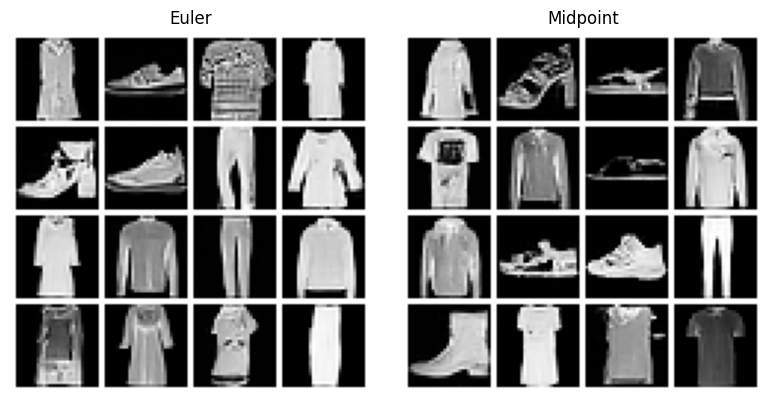

In [20]:
euler_grid = utils.make_grid(sample_rectified_flow_euler(image_flow_model, n_samples=16), nrow=4, pad_value=1.0)
midpoint_grid = utils.make_grid(sample_rectified_flow_midpoint(image_flow_model, n_samples=16), nrow=4, pad_value=1.0)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(euler_grid.permute(1, 2, 0), cmap="gray")
axes[0].set_title("Euler")
axes[0].axis("off")

axes[1].imshow(midpoint_grid.permute(1, 2, 0), cmap="gray")
axes[1].set_title("Midpoint")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## Path Design and Conditioning

The straight interpolation path is attractive because its target velocity is extremely simple. Simplicity can still impose awkward geometry. A path may inject Gaussian variability early on or contract uncertainty more carefully near the data endpoint. This changes the **local supervision targets** and therefore changes the learned field.

```{note}
In flow matching, the **path family defines the training signal**. Changing the path changes the geometry of the regression target seen by the model.
```

A minimal Gaussian-path version keeps the same mean interpolation and adds a time-dependent noise scale:
:::{math}
\boldsymbol{x}_t = \alpha_t \boldsymbol{x}_1 + (1-\alpha_t)\boldsymbol{x}_0 + \sigma_t \boldsymbol{\epsilon}, \qquad \boldsymbol{\epsilon} \sim \mathcal{N}(\boldsymbol{0}, I).
:::
The path is analytically controlled. The additional noise changes the regression targets, and the schedule determines whether this helps or complicates learning.

In [21]:
def sample_gaussian_image_path(x1, sigma_min=0.01):
    x0 = torch.randn_like(x1)
    t = torch.rand(x1.size(0), 1, 1, 1, device=x1.device)
    alpha_t = t
    sigma_t = sigma_min + (1.0 - sigma_min) * (1.0 - t)
    eps = torch.randn_like(x1)
    xt = alpha_t * x1 + (1.0 - alpha_t) * x0 + sigma_t * eps

    # This target is a practical teaching approximation: it isolates the mean transport term.
    ut = x1 - x0
    return x0, x1, xt, ut, t.view(x1.size(0), 1)


def gaussian_path_flow_loss(model, x1):
    _, _, xt, ut, t = sample_gaussian_image_path(x1)
    pred = model(xt, t)
    return F.mse_loss(pred, ut)


This code keeps the path variant deliberately compact. The key methodological point is that **changing the path changes the supervision**. A full implementation would use the exact conditional velocity for the chosen path family.

Conditional generation is one of the most important extensions of the base model. As in conditional VAEs and conditional GANs, the condition turns unconditional generation into **controlled generation**. In FashionMNIST the condition is a class label, so the source randomness is shaped toward a requested object category.

On FashionMNIST the conditioning variable is the class label. The velocity field now answers “where should mass move from here at this time **given the requested class**?” This is a direct form of controlled synthesis.

In [22]:
num_classes = 10
cond_epochs = 25
cond_lr = 2e-4
class_names = fashion_train.classes


In [23]:
class ConditionalImageVelocityUNet(nn.Module):
    def __init__(self, in_channels=1, base_channels=64, time_dim=128, num_classes=10):
        super().__init__()
        self.time_embedding = nn.Sequential(
            TimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )
        self.label_embedding = nn.Embedding(num_classes, time_dim)
        self.input_conv = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)
        self.down1 = ImageResidualBlock(base_channels, base_channels, time_dim)
        self.downsample1 = nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1)
        self.down2 = ImageResidualBlock(base_channels * 2, base_channels * 2, time_dim)
        self.downsample2 = nn.Conv2d(base_channels * 2, base_channels * 4, kernel_size=4, stride=2, padding=1)
        self.down3 = ImageResidualBlock(base_channels * 4, base_channels * 4, time_dim)
        self.mid = ImageResidualBlock(base_channels * 4, base_channels * 4, time_dim)
        self.upsample2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=4, stride=2, padding=1)
        self.up2 = ImageResidualBlock(base_channels * 4, base_channels * 2, time_dim)
        self.upsample1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=4, stride=2, padding=1)
        self.up1 = ImageResidualBlock(base_channels * 2, base_channels, time_dim)
        self.output_conv = nn.Conv2d(base_channels, in_channels, kernel_size=1)

    def forward(self, x, t, labels):
        t_emb = self.time_embedding(t)
        label_emb = self.label_embedding(labels)
        cond_emb = t_emb + label_emb
        x0 = self.input_conv(x)
        x1 = self.down1(x0, cond_emb)
        x2 = self.downsample1(x1)
        x2 = self.down2(x2, cond_emb)
        x3 = self.downsample2(x2)
        x3 = self.down3(x3, cond_emb)
        x_mid = self.mid(x3, cond_emb)
        x_up = self.upsample2(x_mid)
        x_up = torch.cat([x_up, x2], dim=1)
        x_up = self.up2(x_up, cond_emb)
        x_up = self.upsample1(x_up)
        x_up = torch.cat([x_up, x1], dim=1)
        x_up = self.up1(x_up, cond_emb)
        return self.output_conv(x_up)


conditional_flow_model = ConditionalImageVelocityUNet(
    in_channels=image_channels,
    base_channels=image_base_channels,
    time_dim=image_time_dim,
    num_classes=num_classes,
).to(device)
conditional_optimizer = torch.optim.AdamW(conditional_flow_model.parameters(), lr=cond_lr, weight_decay=1e-4)


def conditional_rectified_flow_loss(model, x1, labels):
    _, _, xt, ut, t = sample_image_path(x1)
    pred = model(xt, t, labels)
    return F.mse_loss(pred, ut)


The label embedding changes the role of the network. The model learns a **family** of class-specific transport behaviors that share parameters and differ through conditioning.

In [24]:
conditional_history = []

for epoch in tqdm(range(cond_epochs), desc="Conditional flow epochs"):
    conditional_flow_model.train()
    running_loss = 0.0

    for x1, labels in tqdm(fashion_loader, desc="train", leave=False):
        x1 = x1.to(device)
        labels = labels.to(device)
        conditional_optimizer.zero_grad()
        loss = conditional_rectified_flow_loss(conditional_flow_model, x1, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(conditional_flow_model.parameters(), max_norm=1.0)
        conditional_optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(fashion_loader)
    conditional_history.append(epoch_loss)
    print(f"Epoch {epoch + 1:02d} | conditional rectified-flow loss: {epoch_loss:.6f}")


Conditional flow epochs:   0%|          | 0/25 [00:00<?, ?it/s]

train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 01 | conditional rectified-flow loss: 0.346461


train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 02 | conditional rectified-flow loss: 0.257912


...

Epoch 23 | conditional rectified-flow loss: 0.203907


train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 24 | conditional rectified-flow loss: 0.204581


train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 25 | conditional rectified-flow loss: 0.203593


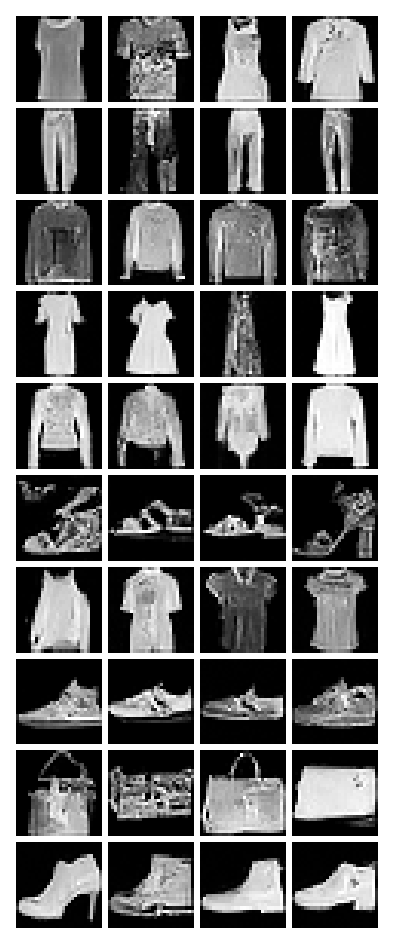

In [25]:
@torch.no_grad()
def sample_conditional_rectified_flow(model, labels, steps=image_ode_steps, show_progress=True):
    model.eval()
    labels = labels.to(device)
    n_samples = labels.size(0)
    x = torch.randn(n_samples, image_channels, image_size, image_size, device=device)
    dt = 1.0 / steps
    iterator = range(steps)
    if show_progress:
        iterator = tqdm(iterator, desc="conditional sampling", leave=False)

    for i in iterator:
        t = torch.full((n_samples, 1), i / steps, device=device)
        v = model(x, t, labels)
        x_mid = x + 0.5 * dt * v
        t_mid = torch.full((n_samples, 1), (i + 0.5) / steps, device=device)
        x = x + dt * model(x_mid, t_mid, labels)

    x = x.clamp(-1.0, 1.0)
    return 0.5 * (x + 1.0).cpu()


label_grid = torch.arange(num_classes).repeat_interleave(4)
conditional_samples = sample_conditional_rectified_flow(conditional_flow_model, label_grid, show_progress=False)
conditional_grid = utils.make_grid(conditional_samples, nrow=4, pad_value=1.0)
plt.figure(figsize=(8, 12))
plt.imshow(conditional_grid.permute(1, 2, 0), cmap="gray")
plt.axis("off")
plt.show()


The expected behavior is stronger than in the unconditional case. Generic clothing-like blobs are insufficient. The row conditioned on “Sandal” should drift toward sandal-like shapes, and the row conditioned on “Bag” should drift toward bag-like shapes. Conditional flow matching is a simple precursor to externally guided generation.

## Evaluation and Failure Modes

When several solvers or variants are compared, recomputing the real-data features wastes time. The metrics below accumulate the real features once and reuse them for repeated fake-sample evaluations.

In [26]:
@torch.no_grad()
def build_real_metric_cache(real_loader, device, num_samples=1000, metric_batch_size=32):
    fid = FrechetInceptionDistance(
        feature=2048,
        normalize=True,
        reset_real_features=False,
    ).set_dtype(torch.float64).to(device)
    kid = KernelInceptionDistance(
        feature=2048,
        subsets=10,
        subset_size=100,
        normalize=True,
        reset_real_features=False,
    ).to(device)

    seen_real = 0
    for real_images, _ in tqdm(real_loader, desc="Caching real features", leave=False):
        remaining = num_samples - seen_real
        if remaining <= 0:
            break
        real_images = real_images[: min(metric_batch_size, remaining)].to(device)
        real_images = 0.5 * (real_images + 1.0)
        real_images = prepare_for_inception_metrics(real_images)
        fid.update(real_images, real=True)
        kid.update(real_images, real=True)
        seen_real += real_images.size(0)

    return fid, kid


@torch.no_grad()
def evaluate_cached_flow_sampler(fid, kid, sampler_fn, device, num_samples=1000, metric_batch_size=32):
    # Create fresh metric objects that reuse the already-computed real statistics.
    eval_fid = copy.deepcopy(fid).to(device)
    eval_kid = copy.deepcopy(kid).to(device)

    generated = 0
    pbar = tqdm(total=num_samples, desc="Cached fake metrics", leave=False)
    while generated < num_samples:
        batch_n = min(metric_batch_size, num_samples - generated)
        fake_images = sampler_fn(batch_n).to(device)
        fake_images = prepare_for_inception_metrics(fake_images)
        eval_fid.update(fake_images, real=False)
        eval_kid.update(fake_images, real=False)
        generated += batch_n
        pbar.update(batch_n)
    pbar.close()

    kid_mean, kid_std = eval_kid.compute()
    return {
        "fid": eval_fid.compute().item(),
        "kid_mean": kid_mean.item(),
        "kid_std": kid_std.item(),
    }


The metric functions above become useful only once the sampler variants are actually compared. The cell below reuses the same cached real features for each sampler and prints the resulting **FID** and **KID** values in a compact table.

In [27]:
metric_num_samples = 1000
metric_batch_size = 32

real_fid_cache, real_kid_cache = build_real_metric_cache(
    fashion_loader,
    device,
    num_samples=metric_num_samples,
    metric_batch_size=metric_batch_size,
)

flow_variant_samplers = {
    "rectified_flow_euler": lambda n: sample_rectified_flow_euler(
        image_flow_model,
        n_samples=n,
        steps=image_ode_steps,
        show_progress=False,
    ),
    "rectified_flow_midpoint": lambda n: sample_rectified_flow_midpoint(
        image_flow_model,
        n_samples=n,
        steps=image_ode_steps,
        show_progress=False,
    ),
    "conditional_rectified_flow": lambda n: sample_conditional_rectified_flow(
        conditional_flow_model,
        labels=torch.arange(n, device=device) % num_classes,
        steps=image_ode_steps,
        show_progress=False,
    ),
}

flow_variant_metrics = {}
for name, sampler_fn in flow_variant_samplers.items():
    flow_variant_metrics[name] = evaluate_cached_flow_sampler(
        real_fid_cache,
        real_kid_cache,
        sampler_fn,
        device,
        num_samples=metric_num_samples,
        metric_batch_size=metric_batch_size,
    )

print("Flow Matching variant metrics")
print(f"{'variant':<30} {'FID':>10} {'KID mean':>12} {'KID std':>12}")
for name, scores in flow_variant_metrics.items():
    print(
        f"{name:<30} "
        f"{scores['fid']:>10.3f} "
        f"{scores['kid_mean']:>12.5f} "
        f"{scores['kid_std']:>12.5f}"
    )


c:\Users\tivog\deep-generative-models\.venv\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Caching real features:   0%|          | 0/469 [00:00<?, ?it/s]

Cached fake metrics:   0%|          | 0/1000 [00:00<?, ?it/s]

Cached fake metrics:   0%|          | 0/1000 [00:00<?, ?it/s]

Cached fake metrics:   0%|          | 0/1000 [00:00<?, ?it/s]

Flow Matching variant metrics
variant                               FID     KID mean      KID std
rectified_flow_euler               29.884      0.00614      0.00143
rectified_flow_midpoint            29.246      0.00433      0.00234
conditional_rectified_flow         35.017      0.01007      0.00331


The exact copying behavior depends on the metric implementation version, so the code uses `copy.deepcopy` for the cached metric objects. The broader pattern is simple: separate the expensive real-data pass from the repeated fake-sample evaluations.

Flow matching has a stable objective, but several problems can still appear:

- The vector field can fit the training interpolation distribution while behaving poorly along generated trajectories.
- The solver can be too coarse even when the training loss looks healthy.
- The path can make the regression target harder than needed.
- The image model can be underpowered for fine-grained modes.

In practice, inspect samples, compare solvers, and state the **path design** explicitly.

```{warning}
A low training loss gives limited evidence about sample quality. The model is trained on sampled interpolation points, while generation follows predicted trajectories. Errors can accumulate along those trajectories.
```

Flow matching is a flexible family of deterministic transport models. Its behavior depends on the **conditional path**, the conditioning mechanism, the architecture, and the ODE solver.